* DI - 725
* Ayça Durmuş
* Assignment 1

In [2]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import altair as alt
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification


import torch
import torch.optim as optim
import torch.nn.functional as F
from torch import nn, Tensor
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
print(device)

cuda


* The following code is AI generated and has been also used in a previous assigment. It is meant to ensure reproducibility.

In [4]:
#the following is a llm-generated code. my aim is to make sure the results are reproducible and do not 
#change everytime i run the code 
import random

def set_seed(seed_value):
    """Set seeds for all sources of randomness."""
    
    # 1. Set seed for Python's built-in random module
    random.seed(seed_value)
    
    # 2. Set seed for NumPy (if you use it for array manipulation)
    np.random.seed(seed_value)
    
    # 3. Set seed for PyTorch (CPU and CUDA)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        # Sets the seed for the current CUDA device
        torch.cuda.manual_seed(seed_value)
        # Sets the seed for all available CUDA devices (if multi-GPU is used)
        torch.cuda.manual_seed_all(seed_value)
    
    # 4. Configure CUDNN for deterministic behavior on GPU
    # This can slightly impact performance but ensures exact reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 5. Set seed for the environment variable for hashing (useful for DataLoader)
    os.environ['PYTHONHASHSEED'] = str(seed_value)

SEED = 42
set_seed(SEED)

In [5]:
data_train=pd.read_csv("train.csv")
print(data_train.columns)
print(len(data_train))
data_train.head()

Index(['issue_area', 'issue_category', 'issue_sub_category',
       'issue_category_sub_category', 'customer_sentiment', 'product_category',
       'product_sub_category', 'issue_complexity', 'agent_experience_level',
       'agent_experience_level_desc', 'conversation'],
      dtype='object')
970


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to...,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...
3,Login and Account,Login Issues and Error Messages,Error message regarding exceeded attempts to e...,Login Issues and Error Messages -> Error messa...,neutral,Appliances,Water Purifier,less,inexperienced,"may struggle with ambiguous queries, rely on c...","Customer: Hi, I am facing an issue while loggi..."
4,Order,Order Delivery Issues,Delivery not attempted again,Order Delivery Issues -> Delivery not attempte...,negative,Electronics,Bp Monitor,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for contacting BrownBox custo...


In [6]:
print(data_train['customer_sentiment'].value_counts())

customer_sentiment
neutral     542
negative    411
positive     17
Name: count, dtype: int64


* The training data has 970 entries and 11 columns. 
* The target variable (customer_sentiment) has 3 levels: neutral, negative, and positive. The distribution of the target variable is not balanced, which means we have to do stratified sampling while splitting this dataset to train and validation subsets.

In [7]:
print(data_train.isnull().sum())
print(data_train.shape)

issue_area                     0
issue_category                 0
issue_sub_category             0
issue_category_sub_category    0
customer_sentiment             0
product_category               0
product_sub_category           0
issue_complexity               0
agent_experience_level         0
agent_experience_level_desc    0
conversation                   0
dtype: int64
(970, 11)


* We have no null values.

In [8]:
print("Average character length of customer conversation:",data_train['conversation'].str.len().mean())
print("Average word length of customer conversation:",data_train['conversation'].str.split().str.len().mean())
word_counts=data_train['conversation'].str.split().str.len()

Average character length of customer conversation: 2129.284536082474
Average word length of customer conversation: 370.86082474226805


* It seems that the average customer interaction is short enough to feed into a transformer model (under 512-token). Let's see the distribution.

C:\Users\USER\AppData\Local\Temp\ipykernel_14860\3063794270.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


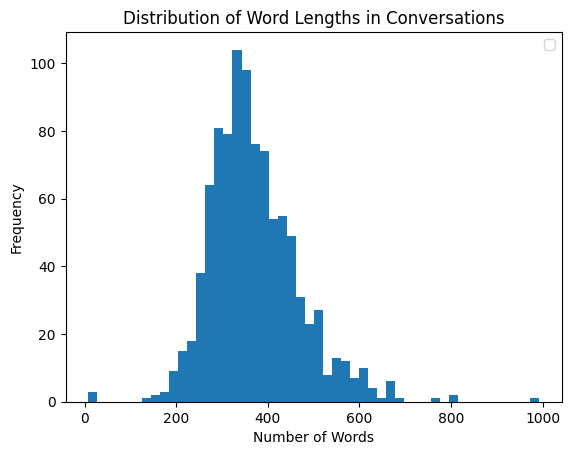

In [9]:
plt.hist(word_counts,bins=50)
plt.title('Distribution of Word Lengths in Conversations')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

* The conversation length in words seem to be normally distributed. Let's do the following:
* Let's check that very short conversation to see if it is valid data point we can use.
* Let's see how many conversations exceed the 512-token length threshold we need for feeding the data into a transformer model.
* Let's see if we can remove some boiler plate text (Like "Have a nice day" or "How can I help you?") that won't tell us much about the customer sentiment analysis. The removal might let us have more conversations we can use within the token limit.
* Note: The conversation length in words do not exactly translate to token length, it is just a rough measure we will use here.

In [10]:
(data_train['conversation'].str.split().str.len()>512).sum()

np.int64(77)

* The following code is AI generated. The goal of this code block is to find frequently used daily phrases / sentences and removing them from the training set to optimize the training. Let's first find the common phrases / sentences.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initialize Vectorizer to look for sequences of 4 to 8 words
# We use a broad range to catch full sentences or common sub-phrases.
vectorizer = CountVectorizer(ngram_range=(4, 8), stop_words=None)
ngram_matrix = vectorizer.fit_transform(data_train['conversation'])

# 2. Calculate frequencies and store in a DataFrame
ngram_counts = pd.DataFrame(
    ngram_matrix.sum(axis=0).T, 
    index=vectorizer.get_feature_names_out(), 
    columns=['frequency']
).sort_values(by='frequency', ascending=False)

# Display the top 20 most frequent long phrases
print(ngram_counts.head(20))

                                      frequency
agent thank you for                        1912
agent you re welcome                       1113
is there anything else                     1026
there anything else can                     966
is there anything else can                  964
sorry to hear that                          923
customer no that all                        899
thank you for your                          897
can assist you with                         851
brownbox customer support my name is        773
support my name is                          773
customer support my name is                 773
brownbox customer support my name           773
brownbox customer support my                773
customer support my name                    773
else can assist you with                    754
anything else can assist you with           754
is there anything else can assist           754
anything else can assist you                754
else can assist you                     

* It seems that the most frequent n-grams are part of a longer sequence. Let's try to increase the n-gram to see if we can find a more coherent sentence so that removing the texts can get easier.

In [12]:
#ai
vectorizer = CountVectorizer(ngram_range=(9, 10), stop_words=None)
ngram_matrix = vectorizer.fit_transform(data_train['conversation'])

# 2. Calculate frequencies and store in a DataFrame
ngram_counts = pd.DataFrame(
    ngram_matrix.sum(axis=0).T, 
    index=vectorizer.get_feature_names_out(), 
    columns=['frequency']
).sort_values(by='frequency', ascending=False)

# Display the top 20 most frequent long phrases
print(ngram_counts.head(20))
pd.set_option('display.max_colwidth', 10)

                                                    frequency
is there anything else can assist you with cust...        546
you for calling brownbox customer support my na...        522
thank you for calling brownbox customer support...        522
thank you for calling brownbox customer support...        522
there anything else can assist you with custome...        519
is there anything else can assist you with cust...        519
anything else can assist you with customer no that        504
there anything else can assist you with custome...        504
anything else can assist you with customer no t...        495
else can assist you with customer no that all             495
agent thank you for calling brownbox customer s...        418
agent thank you for calling brownbox customer s...        418
if you have any further questions or concerns p...        287
thank you for your help agent you re welcome              283
can assist you with customer no that all thank you        261
can assi

* Just to be sure, let's check if these frequent phrases have any impact on the sentiment of the customer.

In [13]:
#ai
#calculation of conditional probability
words = vectorizer.get_feature_names_out()

# 2. Create a DataFrame of n-gram presence joined with sentiment
df_ngrams = pd.DataFrame(ngram_matrix.toarray(), columns=words)
df_ngrams['sentiment'] = data_train['customer_sentiment'].values

# 3. Calculate mean frequency per sentiment (Percentage of documents in class containing the phrase)
sentiment_impact = df_ngrams.groupby('sentiment').mean().T

# Sort by the phrases most common in 'negative' to see what drives frustration
print(sentiment_impact.sort_values(by='negative', ascending=False).head(10))

sentiment   negative   neutral  positive
is ther...  0.564477  0.557196  0.705882
thank y...  0.547445  0.529520  0.588235
you for...  0.547445  0.529520  0.588235
thank y...  0.547445  0.529520  0.588235
there a...  0.537713  0.529520  0.647059
is ther...  0.537713  0.529520  0.647059
anythin...  0.501217  0.529520  0.647059
there a...  0.501217  0.529520  0.647059
else ca...  0.489051  0.522140  0.647059
anythin...  0.489051  0.522140  0.647059


* As we can see, not really. The percentages are more or less distributed equally. We do see some values that are slightly higher in the positive column, however we have a very small sample size for the positive sentiment, hence even one sample can impact the score.
* We will remove these frequent phrases.

In [14]:
#ai
phrases_to_remove = [
    "thank you for calling brownbox customer support my name is",
    "is there anything else can assist you with",
    "customer no that all thank you for your help",
    "if you have any further questions or concerns please",
    "sorry to hear that",
    "thank you for",
    "sorry to hear that"
]
# Create a regex pattern: 'phrase1|phrase2|phrase3'
# The '|' acts as an 'OR' operator in regex
pattern = '|'.join(phrases_to_remove)

# Remove the phrases (case-insensitive)
data_train['conversation'] = data_train['conversation'].str.replace(pattern, '', case=False, regex=True)
# Optional: Strip extra whitespace left behind after removal
data_train['conversation'] = data_train['conversation'].str.strip().str.replace(r'\s+', ' ', regex=True) 

* Let's see the amount of above 512-word sentences left.

In [15]:
(data_train['conversation'].str.split().str.len()>512).sum()

np.int64(57)

* We managed to save some of them!
* Let's now see if the very short conversations are legit data points.

In [16]:
print(data_train[data_train['conversation'].str.split().str.len()<50])
pd.set_option('display.max_colwidth', None)

    issue_area issue_category issue_sub_category issue_category_sub_category  \
191      Order  Order ...      Packag...          Order ...                    
286      Order  Order ...      Packag...          Order ...                    
750      Order  Order ...      Order ...          Order ...                    

    customer_sentiment product_category product_sub_category issue_complexity  \
191   negative          Men/Wo...           Shorts                 less         
286   negative          Men/Wo...          T-Shirt                 less         
750   negative          Applia...        Sandwi...                 less         

    agent_experience_level agent_experience_level_desc conversation  
191     junior              handle...                   Agent:...    
286  inexpe...              may st...                   Agent:...    
750  experi...              confid...                   Agent:...    


* They are not really conversations, so let's delete them.

In [17]:
pd.set_option('display.max_colwidth', None)
data_train=data_train[data_train['conversation'].str.split().str.len()>50]

* Now, let's see how the features in our data correlates with the customer sentiment.

In [18]:
from scipy.stats import chi2_contingency
#ai
def cramers_v(x, y):
    """ Calculate Cramér's V for two categorical series. """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Correct for bias
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# List of categorical columns to check against sentiment
cols = ['issue_area', 'issue_category', 'product_category', 'issue_complexity', 'agent_experience_level','issue_sub_category']

correlations = {col: cramers_v(data_train[col], data_train['customer_sentiment']) for col in cols}
corr_df = pd.Series(correlations).sort_values(ascending=False)

print("Correlation with Customer Sentiment (Cramér's V):")
print(corr_df)

Correlation with Customer Sentiment (Cramér's V):
issue_sub_category        0.943420
issue_category            0.710983
issue_area                0.285379
agent_experience_level    0.053856
product_category          0.037802
issue_complexity          0.000000
dtype: float64


* Based on the Cramer's V feature correlation, issue sub-category, issue category, and issue area are the most relevant features for our model.
* Let's add them to the conversation column so we can train the model with just one input.

In [19]:
data_train['conversation']=data_train['issue_category_sub_category']+"\n"+data_train['issue_area']+"\n"+data_train['conversation']

* For this project, instead of training a transformer model from scratch, I will fine-tune an existing one.
* I will use Bert Mini from hugging face library. The model can be found here: https://huggingface.co/prajjwal1/bert-mini

In [20]:
tokenizer=AutoTokenizer.from_pretrained("prajjwal1/bert-mini") #the model's tokenizer we will use to tokenize the conversation column

* First, I will encode the customer sentiment so it is coded as 0 ,1, and 2.
* Then, I will split the training dataset and use 1/5 of it for validation.

In [21]:
label_encoder=LabelEncoder()
data_train['sentiment']=label_encoder.fit_transform(data_train['customer_sentiment']) #encoding the ground truth

train_set, valid_set = train_test_split(data_train, test_size=0.2, random_state=42, stratify=data_train['customer_sentiment'])
print(len(valid_set))

194


* I will load the test dataset and will concatenate the relevant features to the conversation, the same way we did with the training set. We will also encode the sentiment.

In [22]:
data_test=pd.read_csv("test.csv")
print(len(data_test))

30


In [23]:
data_test['conversation']=data_test['issue_category_sub_category']+"\n"+data_test['issue_area']+"\n"+data_test['conversation']

In [24]:
data_test['sentiment']=label_encoder.transform(data_test['customer_sentiment'])

In [25]:
#oversampling because we have so few positive conversations in the dataset
#ai
# 1. Identify the majority and minority classes within the training set
df_neutral = train_set[train_set['customer_sentiment'] == 'neutral']
df_negative = train_set[train_set['customer_sentiment'] == 'negative']
df_positive = train_set[train_set['customer_sentiment'] == 'positive']

# 2. Oversample the 'positive' class to match the 'neutral' count
# We use replace=True to allow duplicating the same rows multiple times
df_positive_oversampled = df_positive.sample(len(df_neutral), replace=True, random_state=42)

# combining them back
train_set_balanced = pd.concat([df_neutral, df_negative, df_positive_oversampled], axis=0)

# shuffling
train_set_balanced = train_set_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(train_set_balanced['customer_sentiment'].value_counts())

customer_sentiment
positive    433
neutral     433
negative    326
Name: count, dtype: int64


* The custom dataset function will apply the tokenizer to the datasets and will get the word embeddings, as well as the attention mask, and will create new datasets that we will use for the training and testing.

In [26]:
#code taken from a previous assignment. it has been modified to suit the dataset
from torch.utils.data import Dataset
class custom_dataset(Dataset): 
    def __init__(self, dataframe,tokenizer,max_len=512): 
        self.df=dataframe.reset_index(drop=True) #cleaning up the index so that the indices do not get mixed up after train/test/val split
        self.tokenizer=tokenizer
        self.max_len=max_len
    def __len__(self):
        return len(self.df)
    def __getitem__(self,idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        conversation=self.df.iloc[idx]['conversation']
    
        encoding= self.tokenizer(conversation,padding="max_length",truncation=True,max_length=self.max_len,return_tensors='pt')

        sentiment=torch.tensor(self.df.iloc[idx]['sentiment'],dtype=torch.long)

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'sentiment': sentiment # ground truth 
        }

In [27]:
train_dataset=custom_dataset(train_set_balanced,tokenizer)
validation_dataset=custom_dataset(valid_set,tokenizer)
test_dataset=custom_dataset(data_test,tokenizer)

In [28]:
batch_size=8 #i am running the model on my PC, hence the smaller batch size
train_dataloader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_dataloader=DataLoader(validation_dataset, batch_size=batch_size,shuffle=False)
test_dataloader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [30]:
import wandb
wandb.login(key="")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\USER\_netrc.
wandb: Currently logged in as: ayca-durmus (ayca-durmus-middle-east-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [29]:
sweep_config={
    'method':'grid', #for reproducibility
    'metric':  {
        'name': 'loss', #will aim to minimize validation loss
        'goal': 'minimize'
    },
    'parameters': {
        'optimizer':{
            'values':['adam','sgd']
        },
    'fc_layer_size':{
        'values':[128,256,512]
    },
    'learning_rate':{
        'values':[2e-5,3e-5,4e-5,5e-5]
    },
    "epochs":{
        'value':5
    },
    "dropout":{
        'values':[0.3,0.4,0.5]
    }
    }
}

In [31]:
sweep_id=wandb.sweep(sweep_config,project="Sentiment Analysis")

Create sweep with ID: 10pa3jm2
Sweep URL: https://wandb.ai/ayca-durmus-middle-east-technical-university/Sentiment%20Analysis/sweeps/10pa3jm2


In [32]:
#this code cell is taken from a previous project and modified for this assignment as needed
def build_optimizer(network,optimizer,learning_rate):
    if optimizer=="sgd":
        optimizer=optim.SGD(network.parameters(),lr=learning_rate,momentum=0.9)
    elif optimizer=='adam':
        optimizer=optim.Adam(network.parameters(),lr=learning_rate)
    return optimizer

def build_network(fc_layer_size,dropout): 
    model = AutoModelForSequenceClassification.from_pretrained(
        "prajjwal1/bert-mini",
        num_labels=len(label_encoder.classes_)
    )
    n_inputs=model.classifier.in_features #the output layer size of bert-mini
    n_labels=model.num_labels #number of sentiment classes
    model.classifier=torch.nn.Sequential(
        torch.nn.Linear(n_inputs,fc_layer_size),
        torch.nn.ReLU(),
        torch.nn.Dropout(dropout),
        torch.nn.Linear(fc_layer_size,n_labels)
    )
    return model.to(device)

def train_epoch(network,loader,optimizer):
    network.train()
    for param in network.bert.parameters(): 
        param.requires_grad=False
    
    for layer in network.bert.encoder.layer[-1:]: #the model has 4 layers, for optimal finetuning i will try with unfreezing the last one
        for param in layer.parameters():
            param.requires_grad=True

    for param in network.classifier.parameters():
        param.requires_grad=True
            
    cumu_loss=0
    for batch in loader:
        batch={k:v.to(device) for k,v in batch.items()} #moving the data to cuda
        optimizer.zero_grad()

        outputs=network(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['sentiment']
        )
        loss=outputs.loss
        cumu_loss+=loss.item()
        loss.backward()
        optimizer.step()
        wandb.log({"batch_loss": loss.item()})
    return cumu_loss/len(loader)

def validate(network,loader):
    network.eval()
    cumu_loss=0
    with torch.no_grad():
        for batch in loader:
            batch={k:v.to(device) for k,v in batch.items()} #moving the data to cuda
            
            outputs=network(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
                labels=batch['sentiment'] 
            )
            cumu_loss+=outputs.loss.item()
    return cumu_loss/len(loader)

global_best_loss = float('inf')

def train(config=None):
    global global_best_loss 
    
    with wandb.init(config=config):
        config = wandb.config
        network = build_network(config.fc_layer_size, config.dropout)
        optimizer = build_optimizer(network, config.optimizer, config.learning_rate)

        for epoch in range(config.epochs): 
            avg_train_loss = train_epoch(network, train_dataloader, optimizer)
            avg_val_loss = validate(network, val_dataloader)

            if avg_val_loss < global_best_loss:
                global_best_loss = avg_val_loss
                print(f"New best model found. Loss: {global_best_loss:.4f} !!!")
                
                torch.save(network.state_dict(), "best_model_classification.pth")

            wandb.log({
                "loss": avg_val_loss, 
                "train_loss": avg_train_loss,
                "epoch": epoch
            })

In [ ]:
wandb.agent(sweep_id, function=train)

In [33]:
class_names=label_encoder.classes_
print(class_names)

['negative' 'neutral' 'positive']
